In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [14]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [15]:
df = pd.DataFrame(X, columns=['Feature_1','Feature_2'])
df.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

C:\Users\bhart\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
df['kmeans_cluster'] = kmeans_labels
df.head()

,Feature_1,Feature_2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

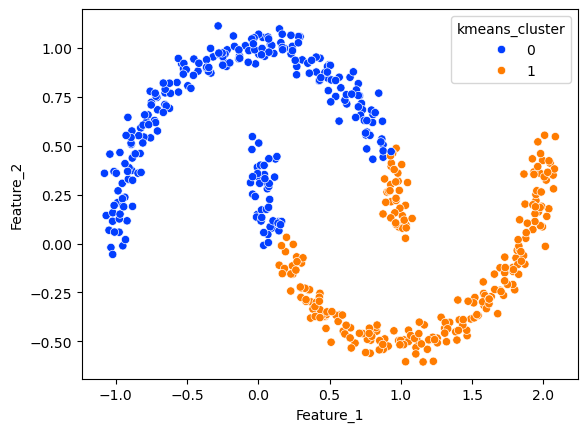

In [22]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['kmeans_cluster'],palette='bright')

In [23]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [24]:
df['dbscan_cluster'] = dbscan_labels
df.head()

,Feature_1,Feature_2,kmeans_cluster,dbscan_cluster
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

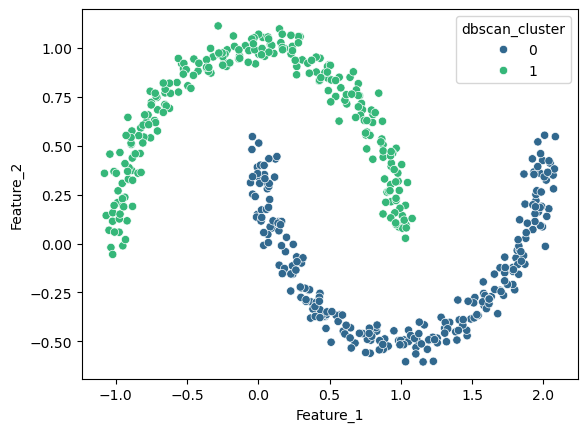

In [25]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['dbscan_cluster'],palette='viridis')